### What is Linear Regression

say you want to predict price of a house based on its size

House Size (sqft) -> Price (lakhs)
800 -> 50
1000 -> 60
1200 -> 70
1400 -> 80

steps we follow -
1. observe the data
2. find out how x (size) and y (price) are related
3. use that relationship to predict y for a new x

say the relation comes out as y = 0.05x + 10
then for x = 1500, y = 0.05*1500 + 10 = 85 lakhs

this is basically linear regression - find a straight line relation between input(s) and output, then use it to predict

used everywhere - predicting sales from ad spend, house price from area/location, student marks from study hours, medical cost from age/condition etc (exactly like this insurance dataset below)

# **LINEAR REGRESSION HANDS-ON**

### Equation of the line

a straight line is written as y = mx + c
m is the slope (how steep the line is)
c is the y-intercept (where line crosses y axis, value of y when x=0)

in real data, points never lie exactly on a straight line (because of noise, measurement errors, natural variation)
linear regression finds the BEST FIT line that minimizes the overall error, this method is called Least Square Fitting

for every point, the vertical distance between the actual value and the line is called error (residual)
e_i = predicted_y - actual_y

we square all these errors and take their average - this is called Mean Squared Error (MSE)
the whole goal of linear regression is to find the m and c that make this MSE as small as possible (closed form solution - solving a 2x2 system for m and c)

when we have more than one input column, the same idea just extends to -
y = b0 + b1*X1 + b2*X2 + b3*X3 ....
where b0 is the intercept and b1,b2,b3 are the coefficients (weight/importance) for each input column

importing the usual libraries - numpy and pandas for handling data, matplotlib and seaborn for plotting graphs

In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# UPLOAD DATA :

loading the dataset here, this has insurance data and we are going to predict the charges column using the rest of the columns

In [237]:
df=pd.read_csv('new_insurance_data.csv')

In [238]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


# ANALYSING AND CLEANING DATA

just checking the first few rows to get a feel of the data - what columns we have and what kind of values they hold

In [239]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [240]:
df.tail()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,170380500.5,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,201515184.8,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,223644981.3,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,252892382.6,3.0,4.006359e+09,southeast,62592.87309
1337,54.0,female,47.410,0.0,yes,63982.80926,31.0,1100328.0,261631699.3,3.0,4.117197e+09,southeast,63770.42801


df.info() gives datatype of every column and also tells how many non null values are there, good first check before cleaning

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

describe() gives statistical summary (mean, min, max, std etc) but only for numeric columns

In [242]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [243]:
df.shape

(1338, 13)

In [244]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [245]:
# CHECKING NULL VALUES:

### Cleaning the data

checking how many missing (null) values are there in each column first

In [246]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [247]:
df.isnull().sum().sum()

np.int64(52)

dropping the rows that have missing values, since the dataset is big enough we can afford to just drop them instead of filling them

In [248]:
df.dropna(inplace=True)

In [249]:
df.isna().sum().sum()

np.int64(0)

In [250]:
# CHECKING DUPLICATE ROWS :

checking if there are any duplicate rows in the data, duplicate rows can make the model biased towards that repeated data

In [251]:
df.duplicated().sum()

np.int64(0)

In [252]:
# OUTLIERS : Extremely high or low values

### Checking Outliers

making a boxplot for every numeric column, boxplot shows the spread of data and the dots outside the whiskers are the outliers

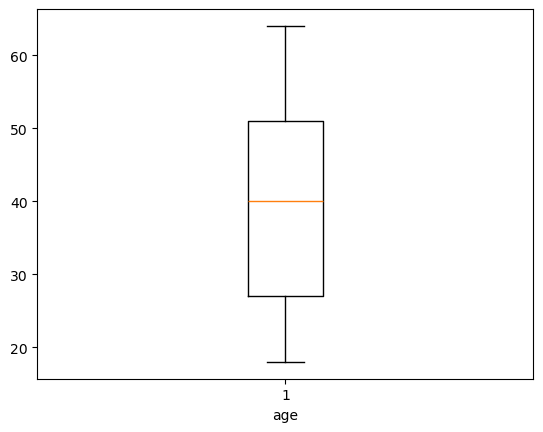

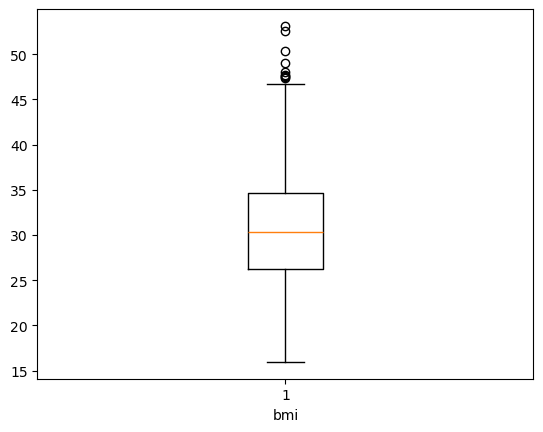

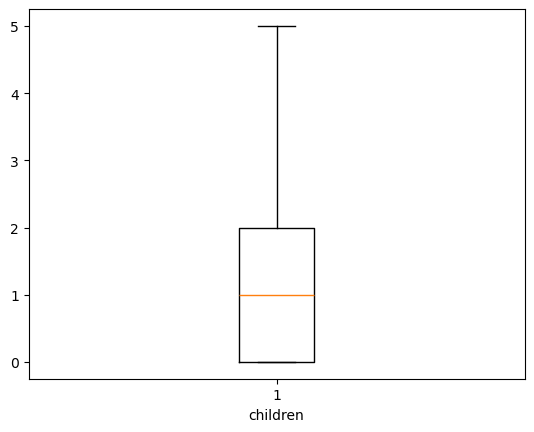

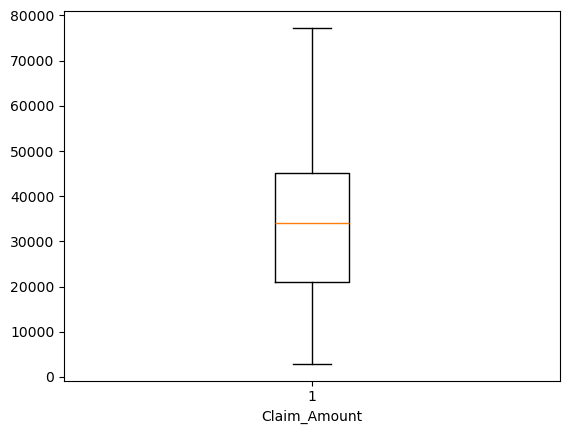

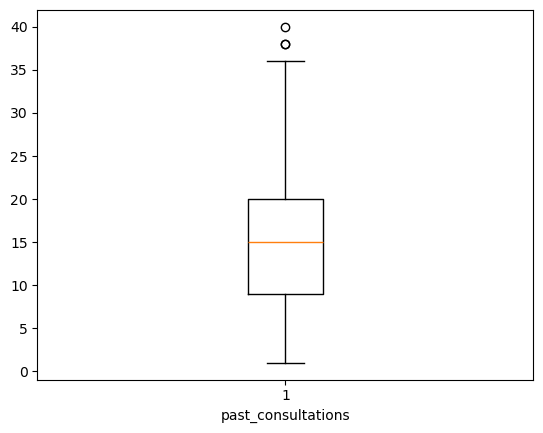

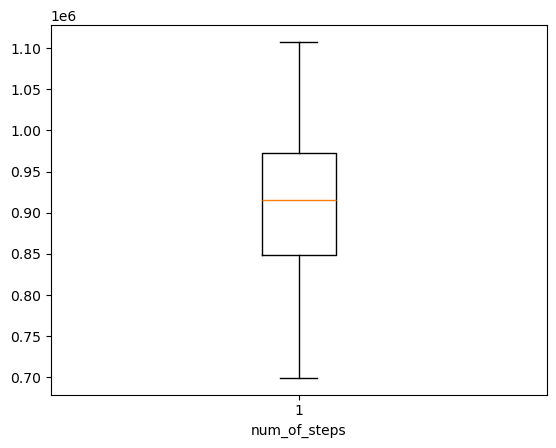

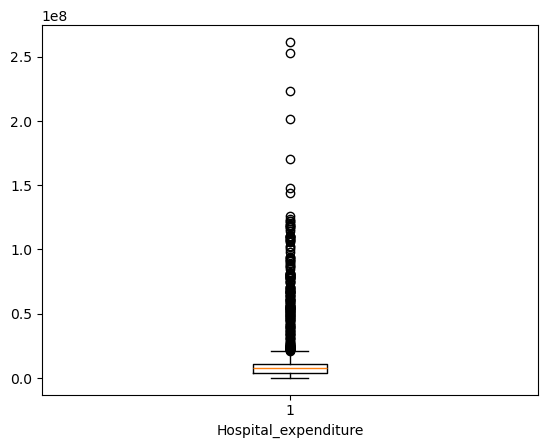

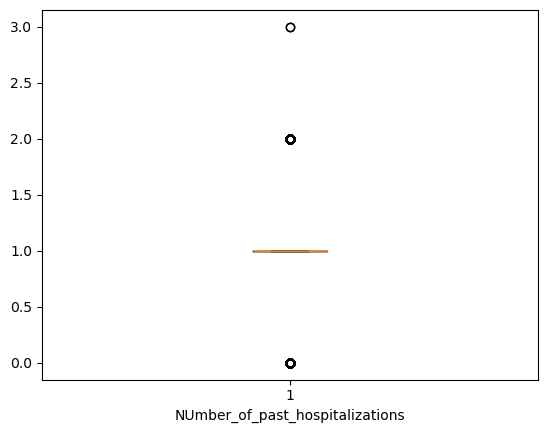

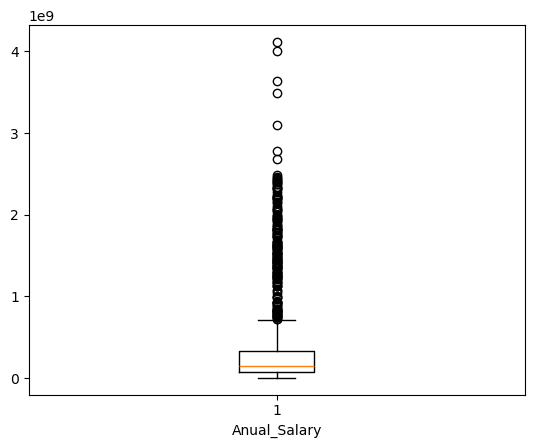

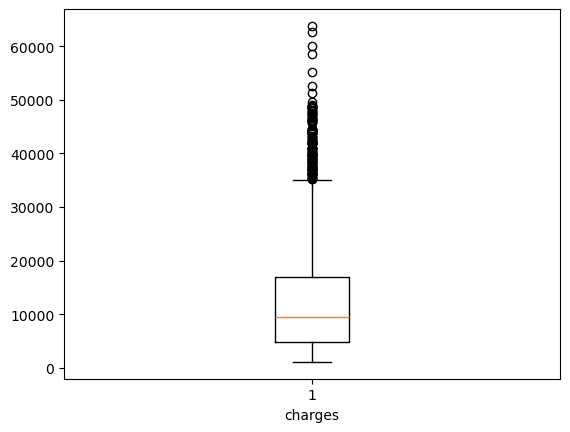

In [253]:
#creating box plot for each columns to check for outlier
for i in df.columns:
  if df[i].dtypes=="int" or df[i].dtypes=="float":
     plt.boxplot(df[i])
     plt.xlabel(i)
     plt.show()

In [254]:
# Should I remove the outliers?

# **Outliers can happen because of->**
# 1) data entry error
# 2) data measurement error and device error
# 3) natural extremes

# **We will not remove the outliers**
# Because outliers are important here, this data can have naturally extreme values.

In [255]:
# Cgpa, Backlogs, Study_hours, Package(Dependent)

In [256]:
# **Independent Variable( Column)- Input**

#They are the columns which decide the output or the dependent data.
#They are the columns which will be used to predict the dependent col. Ex-> Exp, Study Hours, Backlogs, Cgpa

#**Dependent Variable( column)- Output/Result**

#This what we are trying to predict.
#This is dependent on the independent columns.
#Eg- Salary, etc

# Multicollinearity

When there are two or more independent columns or variables are there which are highly correlated with each other. This condtion is called multicollinearity.

Eg-> Independent= Age, Exp, Hours_study, Backlog, Cpga
    
     -Dependent= Salary

**Correlated**-> change in one will result a change in other too.

1) Exp will increase with age( so correlated)

2) Cgpa will increase/decrease with Hours_study

3) Backlogs will decrease with hours_study

**Effect of Multicollinearity**

If we have multicollinearity, there are going to be multiple columns which will have same effect on the dependent column.


1) THis will not have any issue on the prediction of numerical column

2) But, this will effect the feature importance, because when we have multiple columns effecting the output in a same way, model gets confused on which to give more importance.

In [257]:
# Age and Exp are correlated
#Age increase-> salary increase
#Exp increase-> salary increase
#Age and Exp are having same effect on Salary

In [258]:
# y=b0 + b1 X1 + b2 X2 + b3 X3

# VIF

Variance Inflation Factor

Used to check for Multicollinearity.

Higher the VIF-> more than column is correlated with other columns.


In [259]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


importing the function that calculates VIF (variance inflation factor) for checking multicollinearity

In [260]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

picking only the numeric independent columns here (excluding charges since thats our output/target), VIF is only calculated on independent columns

In [261]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'num_of_steps', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations', 'Anual_Salary']


In [262]:
data=df[cols]
print(data)

       age     bmi  children  Claim_Amount  past_consultations  num_of_steps  \
0     18.0  23.210       0.0   29087.54313                17.0      715428.0   
1     18.0  30.140       0.0   39053.67437                 7.0      699157.0   
2     18.0  33.330       0.0   39023.62759                19.0      702341.0   
3     18.0  33.660       0.0   28185.39332                11.0      700250.0   
4     18.0  34.100       0.0   14697.85941                16.0      711584.0   
...    ...     ...       ...           ...                 ...           ...   
1333  33.0  35.530       0.0   63142.25346                32.0     1091267.0   
1334  31.0  38.095       1.0   43419.95227                31.0     1107872.0   
1335  52.0  34.485       3.0   52458.92353                25.0     1092005.0   
1336  45.0  30.360       0.0   69927.51664                34.0     1106821.0   
1337  54.0  47.410       0.0   63982.80926                31.0     1100328.0   

      Hospital_expenditure  NUmber_of_p

In [263]:
vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

                           Columns  VIF
0                              age    0
1                              bmi    0
2                         children    0
3                     Claim_Amount    0
4               past_consultations    0
5                     num_of_steps    0
6             Hospital_expenditure    0
7  NUmber_of_past_hospitalizations    0
8                     Anual_Salary    0


the VIF function needs plain numpy values, not a dataframe, thats why converting it using .values

In [264]:
data.values

array([[1.80000000e+01, 2.32100000e+01, 0.00000000e+00, ...,
        4.72092099e+06, 0.00000000e+00, 5.57849700e+07],
       [1.80000000e+01, 3.01400000e+01, 0.00000000e+00, ...,
        4.32983168e+06, 0.00000000e+00, 1.37008852e+07],
       [1.80000000e+01, 3.33300000e+01, 0.00000000e+00, ...,
        6.88486077e+06, 0.00000000e+00, 7.35231073e+07],
       ...,
       [5.20000000e+01, 3.44850000e+01, 3.00000000e+00, ...,
        2.23644981e+08, 2.00000000e+00, 3.64080668e+09],
       [4.50000000e+01, 3.03600000e+01, 0.00000000e+00, ...,
        2.52892383e+08, 3.00000000e+00, 4.00635850e+09],
       [5.40000000e+01, 4.74100000e+01, 0.00000000e+00, ...,
        2.61631699e+08, 3.00000000e+00, 4.11719664e+09]], shape=(1287, 9))

looping through every column and calculating its VIF value one by one, storing it in the vif dataframe made above

In [265]:
vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

In [266]:
print(vif)

                           Columns        VIF
0                              age  11.889264
1                              bmi  26.415705
2                         children   1.957933
3                     Claim_Amount   6.945681
4               past_consultations   8.586173
5                     num_of_steps  60.555661
6             Hospital_expenditure  27.435063
7  NUmber_of_past_hospitalizations  17.696136
8                     Anual_Salary  37.965843


In [267]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)

data=df[cols]
print(data)

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0
print(vif)

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values


vif

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'num_of_steps', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations', 'Anual_Salary']
       age     bmi  children  Claim_Amount  past_consultations  num_of_steps  \
0     18.0  23.210       0.0   29087.54313                17.0      715428.0   
1     18.0  30.140       0.0   39053.67437                 7.0      699157.0   
2     18.0  33.330       0.0   39023.62759                19.0      702341.0   
3     18.0  33.660       0.0   28185.39332                11.0      700250.0   
4     18.0  34.100       0.0   14697.85941                16.0      711584.0   
...    ...     ...       ...           ...                 ...           ...   
1333  33.0  35.530       0.0   63142.25346                32.0     1091267.0   
1334  31.0  38.095       1.0   43419.95227                31.0     1107872.0   
1335  52.0  34.485       3.0   52458.92353                25.0     1092005.0   
1336  45.0  30.360       0.0   69927.51664  

,Columns,VIF
0,age,11.889264
1,bmi,26.415705
2,children,1.957933
3,Claim_Amount,6.945681
4,past_consultations,8.586173
5,num_of_steps,60.555661
6,Hospital_expenditure,27.435063
7,NUmber_of_past_hospitalizations,17.696136
8,Anual_Salary,37.965843


keeping a copy of the original dataframe here (before dropping any columns) so later we can compare model performance with and without removing multicollinearity

In [268]:
d=df.copy()

### Removing multicollinearity

dropping the column with the highest VIF first, then rechecking VIF again on remaining columns, keep repeating this one column at a time until all VIFs look fine

In [269]:
df=df.drop(["num_of_steps"],axis=1)

In [270]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                           Columns        VIF
0                              age  10.094843
1                              bmi  12.336735
2                         children   1.944907
3                     Claim_Amount   6.389117
4               past_consultations   7.746533
5             Hospital_expenditure  27.374979
6  NUmber_of_past_hospitalizations  15.364271
7                     Anual_Salary  37.876016


In [271]:
df=df.drop(["Anual_Salary"],axis=1)

In [272]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                           Columns        VIF
0                              age   9.873895
1                              bmi  11.182301
2                         children   1.914599
3                     Claim_Amount   6.364278
4               past_consultations   7.324500
5             Hospital_expenditure   2.579248
6  NUmber_of_past_hospitalizations  11.478975


In [273]:
df=df.drop(["NUmber_of_past_hospitalizations"],axis=1)

In [274]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                Columns        VIF
0                   age   8.309772
1                   bmi  11.154995
2              children   1.818798
3          Claim_Amount   6.088357
4    past_consultations   6.919598
5  Hospital_expenditure   1.909801


In [275]:
df=df.drop(["bmi"],axis=1)

In [276]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                Columns       VIF
0                   age  5.753673
1              children  1.786858
2          Claim_Amount  5.313145
3    past_consultations  6.272636
4  Hospital_expenditure  1.891579


In [277]:
print(df)

       age     sex  children smoker  Claim_Amount  past_consultations  \
0     18.0    male       0.0     no   29087.54313                17.0   
1     18.0    male       0.0     no   39053.67437                 7.0   
2     18.0    male       0.0     no   39023.62759                19.0   
3     18.0    male       0.0     no   28185.39332                11.0   
4     18.0    male       0.0     no   14697.85941                16.0   
...    ...     ...       ...    ...           ...                 ...   
1333  33.0  female       0.0    yes   63142.25346                32.0   
1334  31.0  female       1.0    yes   43419.95227                31.0   
1335  52.0    male       3.0    yes   52458.92353                25.0   
1336  45.0    male       0.0    yes   69927.51664                34.0   
1337  54.0  female       0.0    yes   63982.80926                31.0   

      Hospital_expenditure     region      charges  
0             4.720921e+06  southeast   1121.87390  
1             4.3

# Label encoding

Is a way to convert categorical(text) columns to numerical columns.

Because most of the ML models work with numbers.

In [278]:
from sklearn.preprocessing import LabelEncoder

In [279]:
le=LabelEncoder()

for i in df.columns:
  if df[i].dtypes=="object":
    df[i]=le.fit_transform(df[i])

In [280]:
print(df)

       age  sex  children  smoker  Claim_Amount  past_consultations  \
0     18.0    1       0.0       0   29087.54313                17.0   
1     18.0    1       0.0       0   39053.67437                 7.0   
2     18.0    1       0.0       0   39023.62759                19.0   
3     18.0    1       0.0       0   28185.39332                11.0   
4     18.0    1       0.0       0   14697.85941                16.0   
...    ...  ...       ...     ...           ...                 ...   
1333  33.0    0       0.0       1   63142.25346                32.0   
1334  31.0    0       1.0       1   43419.95227                31.0   
1335  52.0    1       3.0       1   52458.92353                25.0   
1336  45.0    1       0.0       1   69927.51664                34.0   
1337  54.0    0       0.0       1   63982.80926                31.0   

      Hospital_expenditure  region      charges  
0             4.720921e+06       2   1121.87390  
1             4.329832e+06       2   1131.50660

# Splitting data into independent(input) and dependent(output)

In [281]:
print(df.columns)

Index(['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region', 'charges'],
      dtype='object')


In [282]:
x=df.loc[:,['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region']]

#                            or

# X = df.drop('charges', axis=1)   # all columns except output/target

# Y = df['charges']                # only output column

y is the dependent variable (output/target) - this is what the model will try to predict, same as y in y=mx+c but now with multiple x's

In [283]:
y=df['charges']

In [284]:
x # independent

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2


In [285]:
y # dependent

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1333    55135.40209
1334    58571.07448
1335    60021.39897
1336    62592.87309
1337    63770.42801
Name: charges, Length: 1287, dtype: float64

# Train and Test Split

In [286]:
from sklearn.model_selection import train_test_split

# x-> input
# y-> output

# 100 - total
# 80 Q/A ->  X_train=Q, Y_Train-> A
# 20 Q/A ->  X_Test= Test Q

#  Y_test=Actual Answers(outputs) for X_Test
#  Y_pred
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

just looking at how the train test split actually divided the data

In [287]:
x_train

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
846,57.0,0,0.0,0,27388.67704,18.0,7.295768e+06,0
1185,32.0,0,2.0,1,35840.97743,22.0,4.262228e+07,1
689,51.0,0,0.0,0,30340.43637,12.0,8.819070e+06,1
1298,29.0,1,2.0,1,29567.96081,28.0,9.217915e+07,3
39,18.0,0,0.0,0,27713.11804,15.0,4.961626e+06,2
...,...,...,...,...,...,...,...,...
306,31.0,1,1.0,0,36435.73042,3.0,2.728160e+06,0
49,18.0,1,0.0,0,44557.44143,20.0,2.617336e+06,0
267,32.0,0,0.0,0,33352.83447,11.0,3.851586e+06,3
137,23.0,1,0.0,0,38358.04156,15.0,2.346913e+06,0


In [288]:
y_train

846     12029.28670
1185    32734.18630
689      9644.25250
1298    44585.45587
39       1634.57340
           ...     
306      4441.21315
49       1704.56810
267      3989.84100
137      2396.09590
772     11013.71190
Name: charges, Length: 1029, dtype: float64

In [289]:
x_test

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
202,26.0,0,0.0,0,22630.605250,9.0,5.490229e+06,1
528,18.0,0,0.0,0,8760.653674,10.0,9.268380e+06,0
702,51.0,0,0.0,0,52777.986870,4.0,6.973392e+06,0
98,21.0,1,0.0,0,21128.775230,7.0,3.748476e+06,0
1174,64.0,0,0.0,1,30108.718630,32.0,3.175397e+07,1
...,...,...,...,...,...,...,...,...
1176,55.0,1,3.0,0,60383.152330,26.0,3.384885e+07,1
1202,27.0,1,1.0,1,58741.571310,24.0,4.549385e+07,2
348,36.0,0,0.0,0,36099.041460,2.0,6.156371e+06,3
1205,45.0,1,0.0,1,46394.245360,22.0,4.892280e+07,0


In [290]:
y_test # actual charge

202      3176.287700
528      7323.734819
702      9866.304850
98       2102.264700
1174    29330.983150
            ...     
1176    30063.580550
1202    34806.467700
348      4883.866000
1205    35069.374520
851     12105.320000
Name: charges, Length: 258, dtype: float64

# Model Building

In [291]:
from sklearn.linear_model import LinearRegression

creating the LinearRegression model objects here (model2 is for a different dataset used later, not this one), sklearn will internally do the least square fitting for us and figure out the best b0,b1,b2... values

In [292]:
model=LinearRegression() #insurance data
model2=LinearRegression() # placement data

**Train The model on x_train,y_train**

In [293]:
model.fit(x_train,y_train) # x-> input # 80%
                           # y-> output

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Predict the output(charges)-> Testing**

In [294]:
y_pred=model.predict(x_test)  # 20% of input -x
                              # predict the output

In [295]:
y_pred

array([ 4460.81040415,  3592.79542311, 10208.38484036,  2788.89123481,
       32943.9223762 , 31559.41138693, 15441.07458993, 13279.40357569,
       12839.05183549, 11166.59544598, 11607.88930817,  2359.92386129,
       10955.60300885, 14523.38522992,  5533.27162931, 20827.10201421,
       13398.89314811, 11465.42770092,  5928.49761324, 12557.48034488,
        7771.41103084, 10163.11359635, 32386.75456094,  8023.11241312,
        3478.51680894,  4073.03046669,  2903.59274081, 11056.28138847,
       19606.15080886,  9998.44030302,  7469.27751862,  9981.55575714,
        5398.99700205, 26651.68833483,  1488.7014645 , 12272.5132696 ,
       27602.69343206,  3790.09417746,  4366.0058992 ,  3719.45835485,
       27765.85817651, 21694.2258043 , 12079.20186148,  4712.20442378,
       46140.13884546,  2140.13701603, 10307.552329  , 31622.57930864,
       15632.53173701, 16183.02074424,  5533.06260209,  9195.26534546,
        8721.67269214, 23765.58782019,  5930.79571996,  5166.7064199 ,
      

In [296]:
y_test

202      3176.287700
528      7323.734819
702      9866.304850
98       2102.264700
1174    29330.983150
            ...     
1176    30063.580550
1202    34806.467700
348      4883.866000
1205    35069.374520
851     12105.320000
Name: charges, Length: 258, dtype: float64

**Comparing the predicted charges with the actual ones**

In [297]:
compare=pd.DataFrame()
compare["Actual Charges"]=y_test
compare["Predicted Charges"]=y_pred
print(compare)

      Actual Charges  Predicted Charges
202      3176.287700        4460.810404
528      7323.734819        3592.795423
702      9866.304850       10208.384840
98       2102.264700        2788.891235
1174    29330.983150       32943.922376
...              ...                ...
1176    30063.580550       22064.894402
1202    34806.467700       29542.178156
348      4883.866000        5370.393959
1205    35069.374520       32627.121394
851     12105.320000       12082.948528

[258 rows x 2 columns]


### Goodness of fit - R2 score

once we have predicted values, we need to check how good our line actually is, thats where R2 (r squared) comes in

R2 tells how much of the variation in output is explained by our input columns, compared to just predicting the average every time

R2 close to 0.8 - 1.0 means good fit (predicted values are close to actual)
R2 close to 0 - 0.3 means poor fit (predicted values are far off from actual)

so higher R2 = better model

# Accuracy of the model-> R2 score

To evaluate how well the model is predicting the output. We have some matrics.

R square tells us how well a regression model is.

This

Cgpa, age, exp, Study -> Package

r2 comes as 0.80. It means 80% of the output happend because of the input. Rest 20% happens because of other factors.

R sq tells us how much better is my model prediction, compared to the avg( or mean)

In [298]:
from sklearn.metrics import r2_score

In [299]:

#         actual  predicted
r=r2_score(y_test,y_pred)
print(r)
# r2( 0 to 1), The higher the r2, the better the prediction

0.9121670521395036


**Applying the Model without removing multicollinearity**

### Trying the model without removing multicollinearity

this whole section below is just to compare - building the same kind of model but on the original data (d) where we did not drop any columns for multicollinearity, so we can see if removing multicollinearity actually improved things or not

In [300]:
le=LabelEncoder()

for i in d.columns:
  if d[i].dtypes=="object":
    d[i]=le.fit_transform(d[i])

In [301]:
print(d.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')


In [302]:
x=d.loc[:,['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region']]

y=d['charges']

splitting this original data into train and test again, same as before

In [303]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [304]:
model3=LinearRegression()

In [305]:
model3.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [306]:
y_pred=model3.predict(x_test)

R2 score

In [307]:
r=r2_score(y_test,y_pred)
print("R_score without removing the VIF=",r)

R_score without removing the VIF= 0.9920219569699731


Freature Inportance-> without removing multicollinearity

In [308]:
print(x_train.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region'],
      dtype='object')


In [309]:
print(model3.coef_)

[-1.50743950e+01  1.23582464e+02 -1.37684850e+00 -1.00624638e+02
  8.68768499e+02  1.34609247e-03  5.57234470e+00  4.99315717e-02
 -1.38865422e-04 -6.14444143e+02  2.06434379e-05 -8.96169302e+00]


In [310]:
coef=pd.DataFrame({
    "Features":x_train.columns,
    "Importance":model3.coef_
})
print(coef)

                           Features  Importance
0                               age  -15.074395
1                               sex  123.582464
2                               bmi   -1.376848
3                          children -100.624638
4                            smoker  868.768499
5                      Claim_Amount    0.001346
6                past_consultations    5.572345
7                      num_of_steps    0.049932
8              Hospital_expenditure   -0.000139
9   NUmber_of_past_hospitalizations -614.444143
10                     Anual_Salary    0.000021
11                           region   -8.961693


plotting predicted vs actual values, if the model was perfect all the points would fall exactly on the red line, more scattered points means more error in prediction

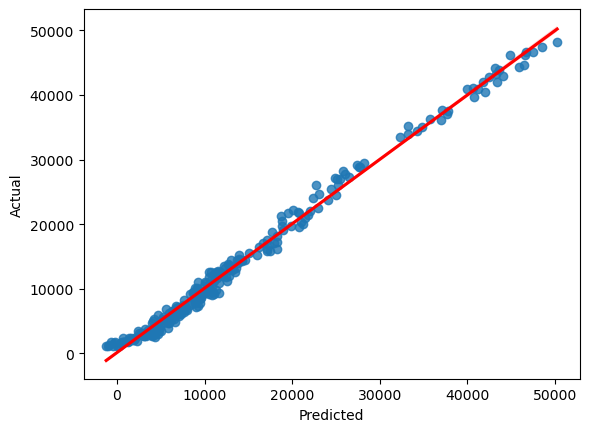

In [311]:
sb.regplot(x=y_pred,y=y_test,line_kws={"color":"red"})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()